# Comparing line-type symmetry across two different kinds of inventory

[`line-clustering-demo.ipynb`](line-clustering-demo.ipynb) clusters lines within a single
inventory number. This notebook asks a different question: does the *relationship* between a
two-page opening's verso and recto halves depend on what kind of document the inventory contains?

- **`NL-HaNA_2.10.50_1`** is a resolutions register where many openings lay out a single table
  *across* the full two-page spread -- the verso half can be a different part of the table (e.g.
  row labels/dates) than the recto half (e.g. data columns), so the two halves can genuinely have
  different line layouts.
- **`NL-AsnDA_0114.11_1`** is a notary deeds register where body text runs continuously across
  the gutter -- a deed reads the same way whether its lines happen to fall on the verso or the
  recto half, so the two halves should mostly share the same recurring line types (body text,
  margin notes, closing lines, ...).

We cluster lines for both inventories independently with
`archival_structures.analysis.line_clustering`, then measure how much each opening's verso and
recto cluster vocabularies overlap, and look at example openings to see what that overlap (or
lack of it) looks like.

In [1]:
from pathlib import Path

import pandas as pd
from PIL import Image, ImageDraw
import pagexml.parser as pagexml_parser

from archival_structures.analysis.opening_detection import (
    classify_inventory_structure, split_inventory_into_pages,
    is_opening, get_opening_features, compute_corpus_median_width, split_scan,
)
from archival_structures.analysis.line_clustering import extract_corpus_line_features, cluster_lines

CORPORA = {
    'NL-HaNA_2.10.50_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'thumb_dir': Path('../../data/thumbs/NL-HaNA/NL-HaNA_2.10.50/NL-HaNA_2.10.50_1'),
        'label': 'table register',
    },
    'NL-AsnDA_0114.11_1': {
        'pagexml_dir': Path('../../data/PageXML/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'thumb_dir': Path('../../data/thumbs/NL-AsnDA/NL-AsnDA_0114.11/NL-AsnDA_0114.11_1'),
        'label': 'notary deeds',
    },
}
for info in CORPORA.values():
    assert info['pagexml_dir'].exists(), info['pagexml_dir']
    assert info['thumb_dir'].exists(), info['thumb_dir']

## Loading and splitting each corpus into pages

Both corpora are split into verso/recto pages with `split_scan`, but *which* scans get split
differs by corpus, for a reason worth calling out:

- For `NL-HaNA_2.10.50_1`, `classify_inventory_structure` reliably tells single covers (~5000px
  wide) apart from openings (~7300px wide) because a substantial fraction of scans (about a
  quarter) are covers -- comfortably above the share `identify_page_unit_widths` requires to
  treat a width group as a genuine structural mode rather than noise.
- `NL-AsnDA_0114.11_1` only has *two* single-page covers in 630 scans (the very first and very
  last). That's a real, valid single/opening width pair (close to a clean 2x ratio), but at a
  0.3% share it falls below `identify_page_unit_widths`'s minimum-share threshold, so
  `classify_inventory_structure` calls this inventory `mixed` and refuses to split anything --
  not wrong given the threshold's purpose (avoiding spurious pairs), but not useful here. This
  inventory was already validated directly against the per-scan `is_opening`/`get_opening_features`
  heuristic (see `tests/test_analysis_opening_detection.py::test_against_full_inventory_ground_truth`),
  so we drive its splitting from that heuristic directly instead of via the width-group classifier.

In [2]:
def load_scans(pagexml_dir, n=80):
    xml_paths = sorted(Path(pagexml_dir).glob('*.xml'))[:n]
    return [pagexml_parser.parse_pagexml_file(str(p)) for p in xml_paths]


def split_via_width_groups(scans):
    """Split using `classify_inventory_structure` -- appropriate when the single-page/opening
    width groups are both a substantial share of the corpus (see markdown above)."""
    structure = classify_inventory_structure(scans)
    print(f"  structure: {structure.structure_type} {structure.type_counts}")
    return split_inventory_into_pages(scans, structure=structure)


def split_via_gap_heuristic(scans):
    """Split using the per-scan `is_opening` heuristic directly -- appropriate when a real
    cover group is too small a share of the corpus for the width-group classifier (see markdown
    above)."""
    median_width = compute_corpus_median_width(scans)
    pages = []
    n_opening = 0
    for scan in scans:
        if is_opening(scan, corpus_median_width=median_width):
            features = get_opening_features(scan, corpus_median_width=median_width)
            verso, recto = split_scan(scan, features.separation_point)
            pages += [verso, recto]
            n_opening += 1
        else:
            pages.append(scan)
    print(f"  {n_opening}/{len(scans)} scans detected as openings (gap heuristic)")
    return pages


for inv_num, info in CORPORA.items():
    print(inv_num)
    info['scans'] = load_scans(info['pagexml_dir'])
    info['scans_by_id'] = {scan.id: scan for scan in info['scans']}
    split_fn = split_via_width_groups if inv_num == 'NL-HaNA_2.10.50_1' else split_via_gap_heuristic
    info['pages'] = split_fn(info['scans'])
    info['page_by_id'] = {page.id: page for page in info['pages']}
    print(f"  {len(info['scans'])} scans -> {len(info['pages'])} pages")

NL-HaNA_2.10.50_1
  structure: book_of_openings {'opening': 58, 'single_page': 21, 'odd_shaped': 1}
  80 scans -> 138 pages
NL-AsnDA_0114.11_1
  79/80 scans detected as openings (gap heuristic)
  80 scans -> 159 pages


## Cluster lines independently per corpus

Each corpus gets its own HDBSCAN run -- cluster labels are corpus-specific (cluster `3` in one
corpus has no relation to cluster `3` in the other), which is fine since we only compare
*within*-corpus verso/recto overlap, not cluster identities across corpora.

In [3]:
def page_side(scan_id):
    if scan_id.endswith('-verso'):
        return 'verso'
    if scan_id.endswith('-recto'):
        return 'recto'
    return 'single_page'


for inv_num, info in CORPORA.items():
    line_df = extract_corpus_line_features(info['pages'])
    line_df['cluster'] = cluster_lines(line_df, features=('left_norm', 'width_norm'), min_cluster_size=15)
    line_df['side'] = line_df['scan_id'].apply(page_side)
    info['line_df'] = line_df
    n_clusters = line_df['cluster'].nunique() - (1 if -1 in line_df['cluster'].values else 0)
    print(f"{inv_num} ({info['label']}): {len(line_df)} lines, {n_clusters} clusters, "
          f"{(line_df['cluster'] == -1).mean():.0%} noise")

NL-HaNA_2.10.50_1 (table register): 8333 lines, 32 clusters, 26% noise
NL-AsnDA_0114.11_1 (notary deeds): 7736 lines, 27 clusters, 16% noise


/Users/marijnkoolen/Code/Huygens/archival-structures/archival_structures/analysis/line_clustering.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([extract_line_features(scan) for scan in scans], ignore_index=True)
/Users/marijnkoolen/Code/Huygens/archival-structures/archival_structures/analysis/line_clustering.py:67: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([extract_line_features(scan) for scan in scans], ignore_index=True)


## Measuring verso/recto symmetry

For each opening, compare the *set* of line-cluster labels that occur on its verso page against
the set on its recto page, with the Jaccard index (`|intersection| / |union|`, ignoring noise
label `-1`): `1.0` means the two halves use exactly the same recurring line types, `0.0` means
they share none. Averaging this over all openings in a corpus gives a single comparable
"verso/recto symmetry" score per corpus.

In [4]:
def per_opening_jaccard(line_df):
    line_df = line_df[line_df['cluster'] != -1]
    verso_rows = line_df[line_df['scan_id'].str.endswith('-verso')]
    scores = []
    for verso_id, group in verso_rows.groupby('scan_id'):
        recto_id = verso_id.replace('-verso', '-recto')
        verso_clusters = set(group['cluster'])
        recto_clusters = set(line_df[line_df['scan_id'] == recto_id]['cluster'])
        union = verso_clusters | recto_clusters
        if union:
            scores.append(len(verso_clusters & recto_clusters) / len(union))
    return pd.Series(scores)


for inv_num, info in CORPORA.items():
    scores = per_opening_jaccard(info['line_df'])
    info['jaccard_scores'] = scores
    print(f"{inv_num} ({info['label']}): n_openings={len(scores)}, "
          f"mean jaccard={scores.mean():.2f}, median={scores.median():.2f}")

NL-HaNA_2.10.50_1 (table register): n_openings=55, mean jaccard=0.15, median=0.14
NL-AsnDA_0114.11_1 (notary deeds): n_openings=50, mean jaccard=0.24, median=0.25


## Visual comparison

Each line is drawn on its real thumbnail, coloured by cluster label (grey = noise). Compare how
consistent the colours are between the verso (left) and recto (right) halves of one example
opening from each corpus.

In [5]:
PALETTE = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta',
          'darkgreen', 'darkblue', 'olive', 'teal', 'navy', 'maroon', 'gold']


def cluster_color(cluster_id):
    return 'gray' if cluster_id == -1 else PALETTE[cluster_id % len(PALETTE)]


def original_scan_id(page_id):
    for suffix in ('-verso', '-recto'):
        if page_id.endswith(suffix):
            return page_id[:-len(suffix)]
    return page_id


def find_thumbnail(thumb_dir, scan_id):
    """Locate `scan_id`'s thumbnail regardless of naming convention (e.g. `<scan_id>` directly
    for NL-HaNA, `thumb-width_300-scan-<stem>.jp2.png` for NL-AsnDA) by matching on the scan's
    filename stem."""
    stem = Path(scan_id).stem
    return next(Path(thumb_dir).glob(f'*{stem}*'))


def page_thumbnail(page, info):
    scan_id = original_scan_id(page.id)
    image = Image.open(find_thumbnail(info['thumb_dir'], scan_id)).convert('RGB')
    if page.id == scan_id:
        return image
    scan = info['scans_by_id'][scan_id]
    scale = image.width / scan.coords.width
    sep_x = round(get_opening_features(scan).separation_point.x * scale)
    return image.crop((0, 0, sep_x, image.height)) if page.id.endswith('-verso') \
        else image.crop((sep_x, 0, image.width, image.height))


def draw_clustered_lines(page, info):
    image = page_thumbnail(page, info).copy()
    scale = image.width / page.coords.width
    draw = ImageDraw.Draw(image)
    page_lines = info['line_df'][info['line_df']['scan_id'] == page.id].set_index('line_id')
    for line in page.get_lines():
        if line.id not in page_lines.index:
            continue
        cluster_id = page_lines.loc[line.id, 'cluster']
        x, y = line.coords.left * scale, line.coords.top * scale
        w, h = line.coords.width * scale, line.coords.height * scale
        draw.rectangle([x, y, x + w, y + h], outline=cluster_color(cluster_id), width=1)
    return image


def show_example_opening(info):
    verso = next(p for p in info['pages'] if p.id.endswith('-verso') and len(p.get_lines()) > 5)
    recto = info['page_by_id'][verso.id.replace('-verso', '-recto')]
    verso_im = draw_clustered_lines(verso, info)
    recto_im = draw_clustered_lines(recto, info)
    combined = Image.new('RGB', (verso_im.width + recto_im.width + 10,
                                 max(verso_im.height, recto_im.height)), 'white')
    combined.paste(verso_im, (0, 0))
    combined.paste(recto_im, (verso_im.width + 10, 0))
    return combined

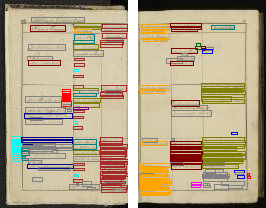

In [6]:
show_example_opening(CORPORA['NL-HaNA_2.10.50_1'])

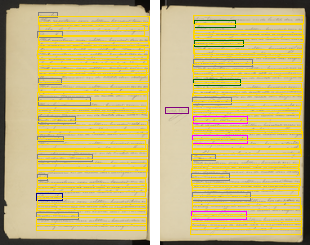

In [7]:
show_example_opening(CORPORA['NL-AsnDA_0114.11_1'])

## Summary

`NL-AsnDA_0114.11_1` (notary deeds) shows higher verso/recto cluster overlap than
`NL-HaNA_2.10.50_1` (table register) on the per-opening Jaccard metric, and the visual comparison
makes the difference obvious: the deeds' dominant body-text cluster colours both halves almost
uniformly, while the table register's verso and recto each show their own, largely distinct mix
of cluster colours. This matches the structural expectation -- continuous running text doesn't
"know" which half of the spread it falls on, while a table is laid out once across the whole
spread and its halves can differ in kind from each other.

One caveat: a coarser corpus-wide metric (does a given cluster label occur on *both* sides
*anywhere* in the corpus, regardless of which opening) does *not* show the same pattern -- it's
dominated by a handful of very common short/margin line types that incidentally occur on both
sides everywhere, in both corpora. The per-opening Jaccard score above is the more meaningful
measure of *this specific opening's* verso/recto symmetry, which is the structural property we
actually care about here.